# **1. Imports & Configuration**

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings

# ── Aesthetic config ──────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})
PALETTE = sns.color_palette('Set2')
print('All libraries loaded successfully')

All libraries loaded successfully


# **2. Load Dataset**

In [54]:
df = pd.read_csv('/kaggle/input/datasets/nudratabbas/ai-worker-burnout-and-attrition-risk-dataset/ai_worker_burnout_attrition_2026.csv')       
df.head()


,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium


In [55]:
# Normalize all column names to lowercase with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns.tolist())
warnings.filterwarnings('ignore')

['employee_id', 'job_role', 'years_experience', 'education_level', 'country', 'industry', 'company_size', 'remote_work_type', 'team_size', 'salary_usd_k', 'primary_ai_tool', 'ai_tools_used_per_day', 'hours_with_ai_assistance_daily', 'ai_replaces_my_tasks_pct', 'ai_adoption_stage', 'weekly_ai_upskilling_hrs', 'productivity_score', 'burnout_score', 'job_satisfaction_1_5', 'fear_of_ai_replacement', 'attrition_risk']


# **3. Statistical Analysis**

# 3.1 Data Types & Schema

In [56]:
print('--- Data Types ---')
print(df.dtypes)
print('\n--- Unique values per column ---')
print(df.nunique())

--- Data Types ---
employee_id                        object
job_role                           object
years_experience                    int64
education_level                    object
country                            object
industry                           object
company_size                       object
remote_work_type                   object
team_size                           int64
salary_usd_k                        int64
primary_ai_tool                    object
ai_tools_used_per_day               int64
hours_with_ai_assistance_daily    float64
ai_replaces_my_tasks_pct            int64
ai_adoption_stage                  object
weekly_ai_upskilling_hrs          float64
productivity_score                  int64
burnout_score                       int64
job_satisfaction_1_5              float64
fear_of_ai_replacement             object
attrition_risk                     object
dtype: object

--- Unique values per column ---
employee_id                       1500
job_role    

this is to get the data types and the unique values per columns

# 3.2 Descriptive Statistics — Numerical Features

In [57]:
df.describe(include=[np.number]).T.style.background_gradient(cmap='Blues', subset=['mean','std','50%'])

,count,mean,std,min,25%,50%,75%,max
years_experience,1500.000000,9.947333,5.460932,1.000000,5.000000,10.000000,15.000000,19.000000
team_size,1500.000000,24.812667,13.682582,2.000000,13.000000,25.000000,36.000000,49.000000
salary_usd_k,1500.000000,140.734000,59.717429,40.000000,91.000000,139.000000,190.000000,249.000000
ai_tools_used_per_day,1500.000000,4.056000,1.974030,1.000000,2.000000,4.000000,6.000000,7.000000
hours_with_ai_assistance_daily,1500.000000,4.233733,2.148387,0.500000,2.400000,4.200000,6.100000,8.000000
ai_replaces_my_tasks_pct,1500.000000,41.248667,21.658214,5.000000,22.750000,40.000000,60.000000,79.000000
weekly_ai_upskilling_hrs,1500.000000,4.985533,2.913933,0.000000,2.400000,5.000000,7.500000,10.000000
productivity_score,1500.000000,57.543333,10.726952,25.000000,50.000000,57.000000,65.000000,95.000000
burnout_score,1500.000000,50.057333,11.437771,16.000000,42.000000,50.000000,58.000000,86.000000
job_satisfaction_1_5,1500.000000,3.334733,0.636692,1.300000,2.900000,3.300000,3.800000,5.000000


# 3.3 Descriptive Statistics — Categorical Features

In [58]:
df.describe(include=['object']).T

,count,unique,top,freq
employee_id,1500,1500,EMP1500,1
job_role,1500,12,Software Engineer,150
education_level,1500,5,Master,323
country,1500,10,France,178
industry,1500,10,Gaming,171
company_size,1500,5,Mid (200-1000),317
remote_work_type,1500,3,Hybrid,599
primary_ai_tool,1500,8,Midjourney,214
ai_adoption_stage,1500,4,Integrating,492
fear_of_ai_replacement,1500,3,Medium,619


# **4. Visual Analysis**

# 4.1 Distribution of All Numerical Features

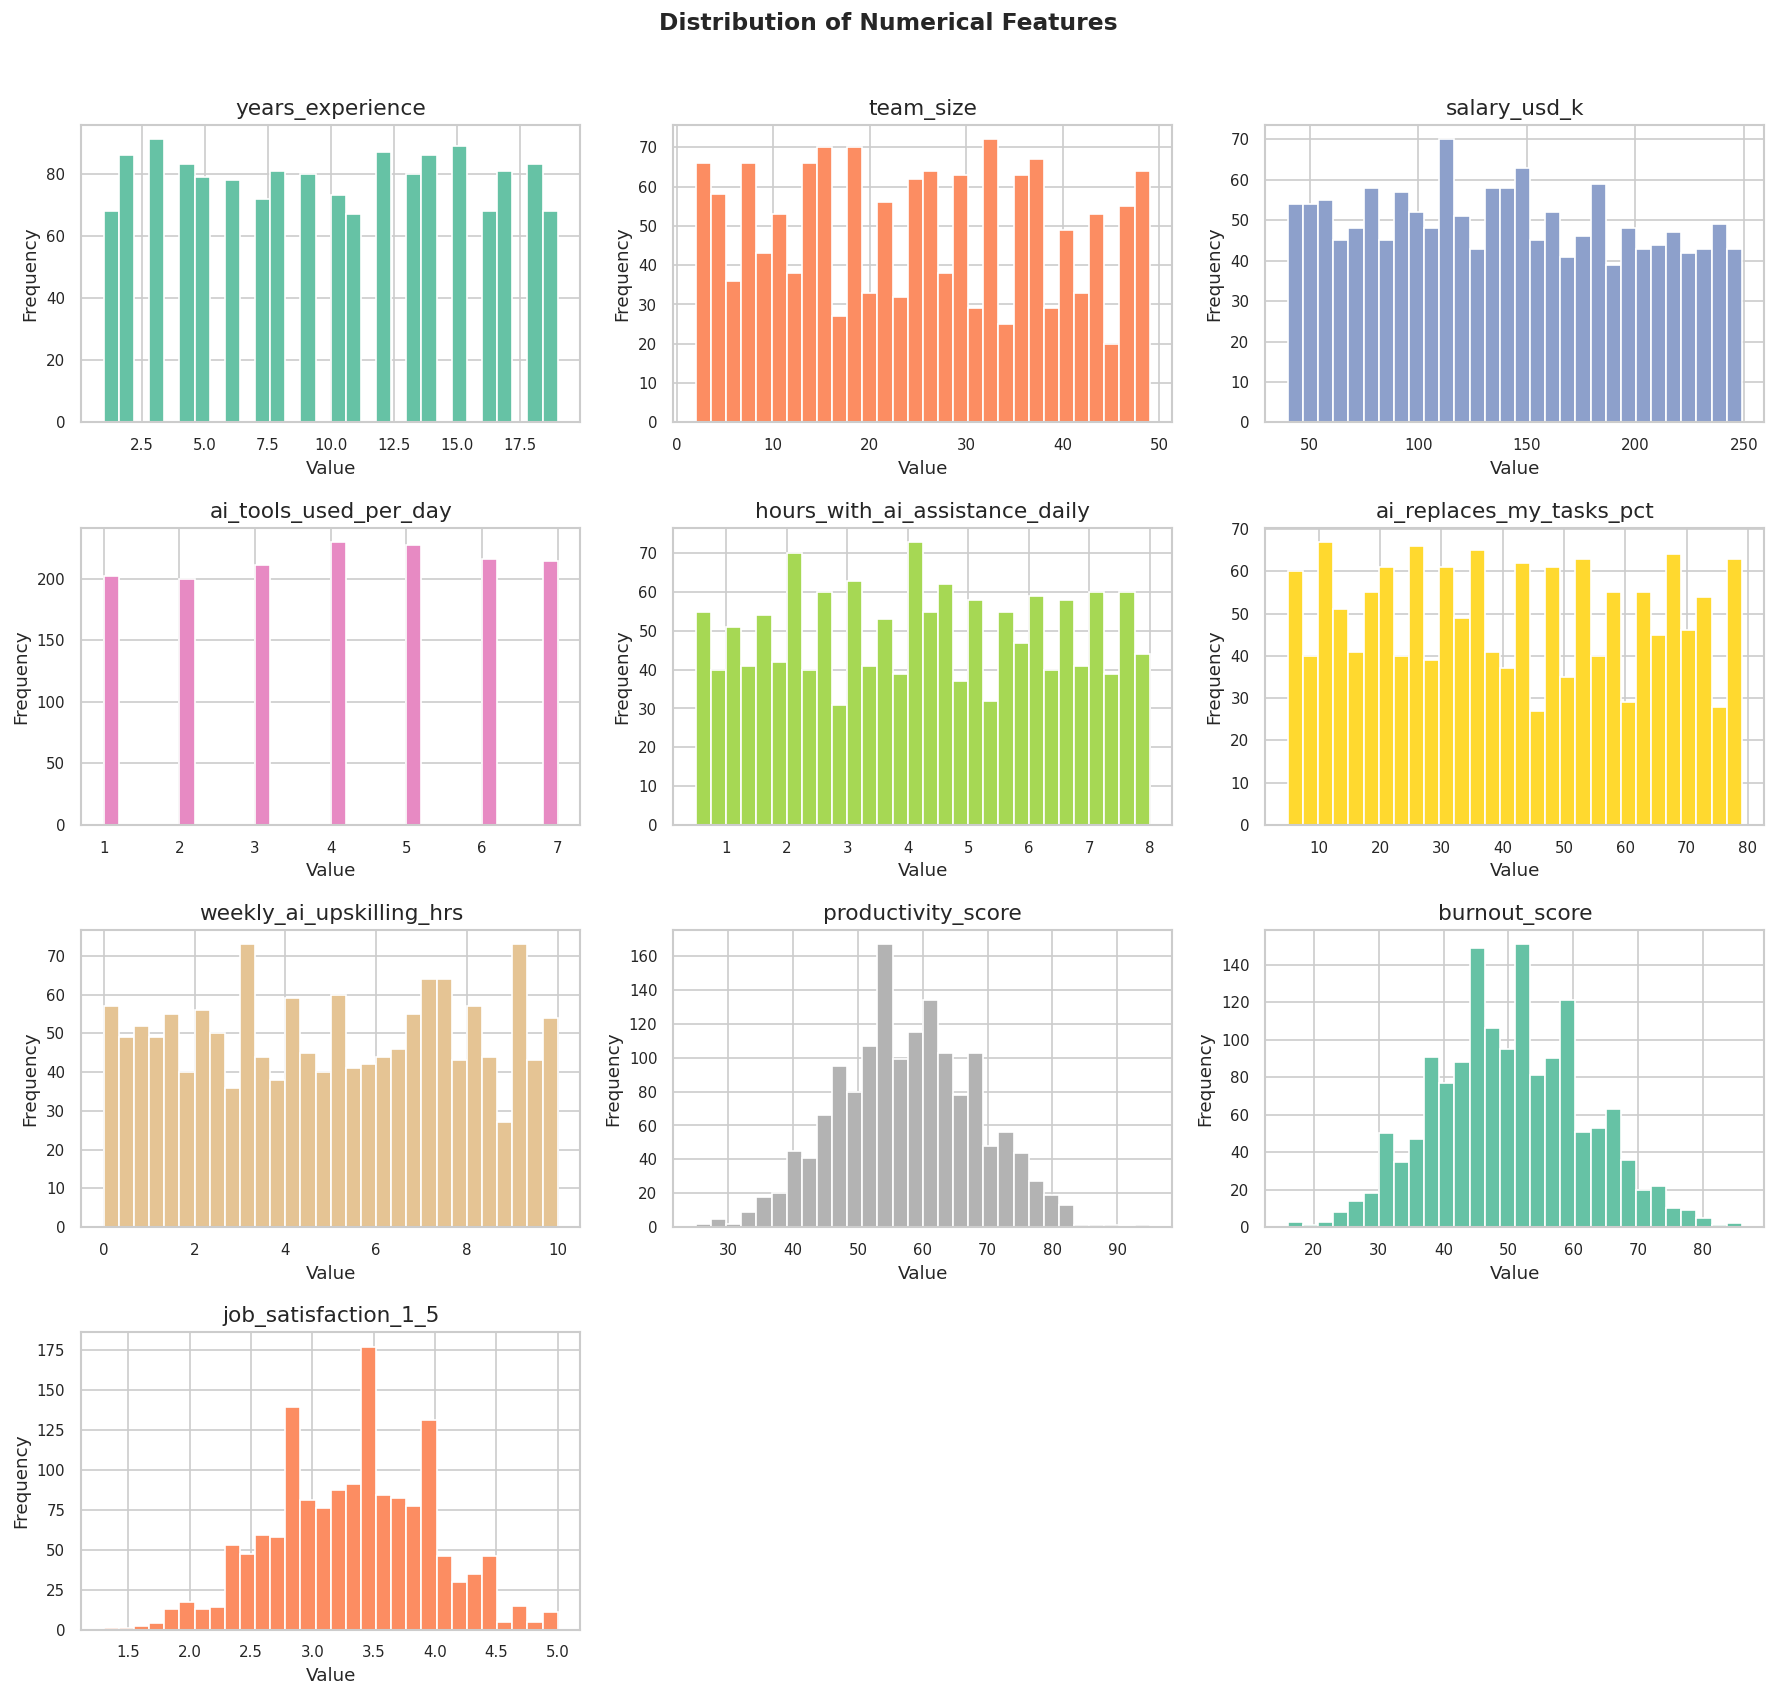

In [59]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove binary/target-looking columns from pure distribution plot
plot_num = [c for c in num_cols if df[c].nunique() > 5]

n = len(plot_num)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(plot_num):
    axes[i].hist(df[col].dropna(), bins=30, color=PALETTE[i % len(PALETTE)], edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 4.2 Box Plots — Outlier Detection

Box plots help us identify outliers in numerical features. Extreme outliers could distort distance-based models (KNN, SVM) and must be handled in preprocessing

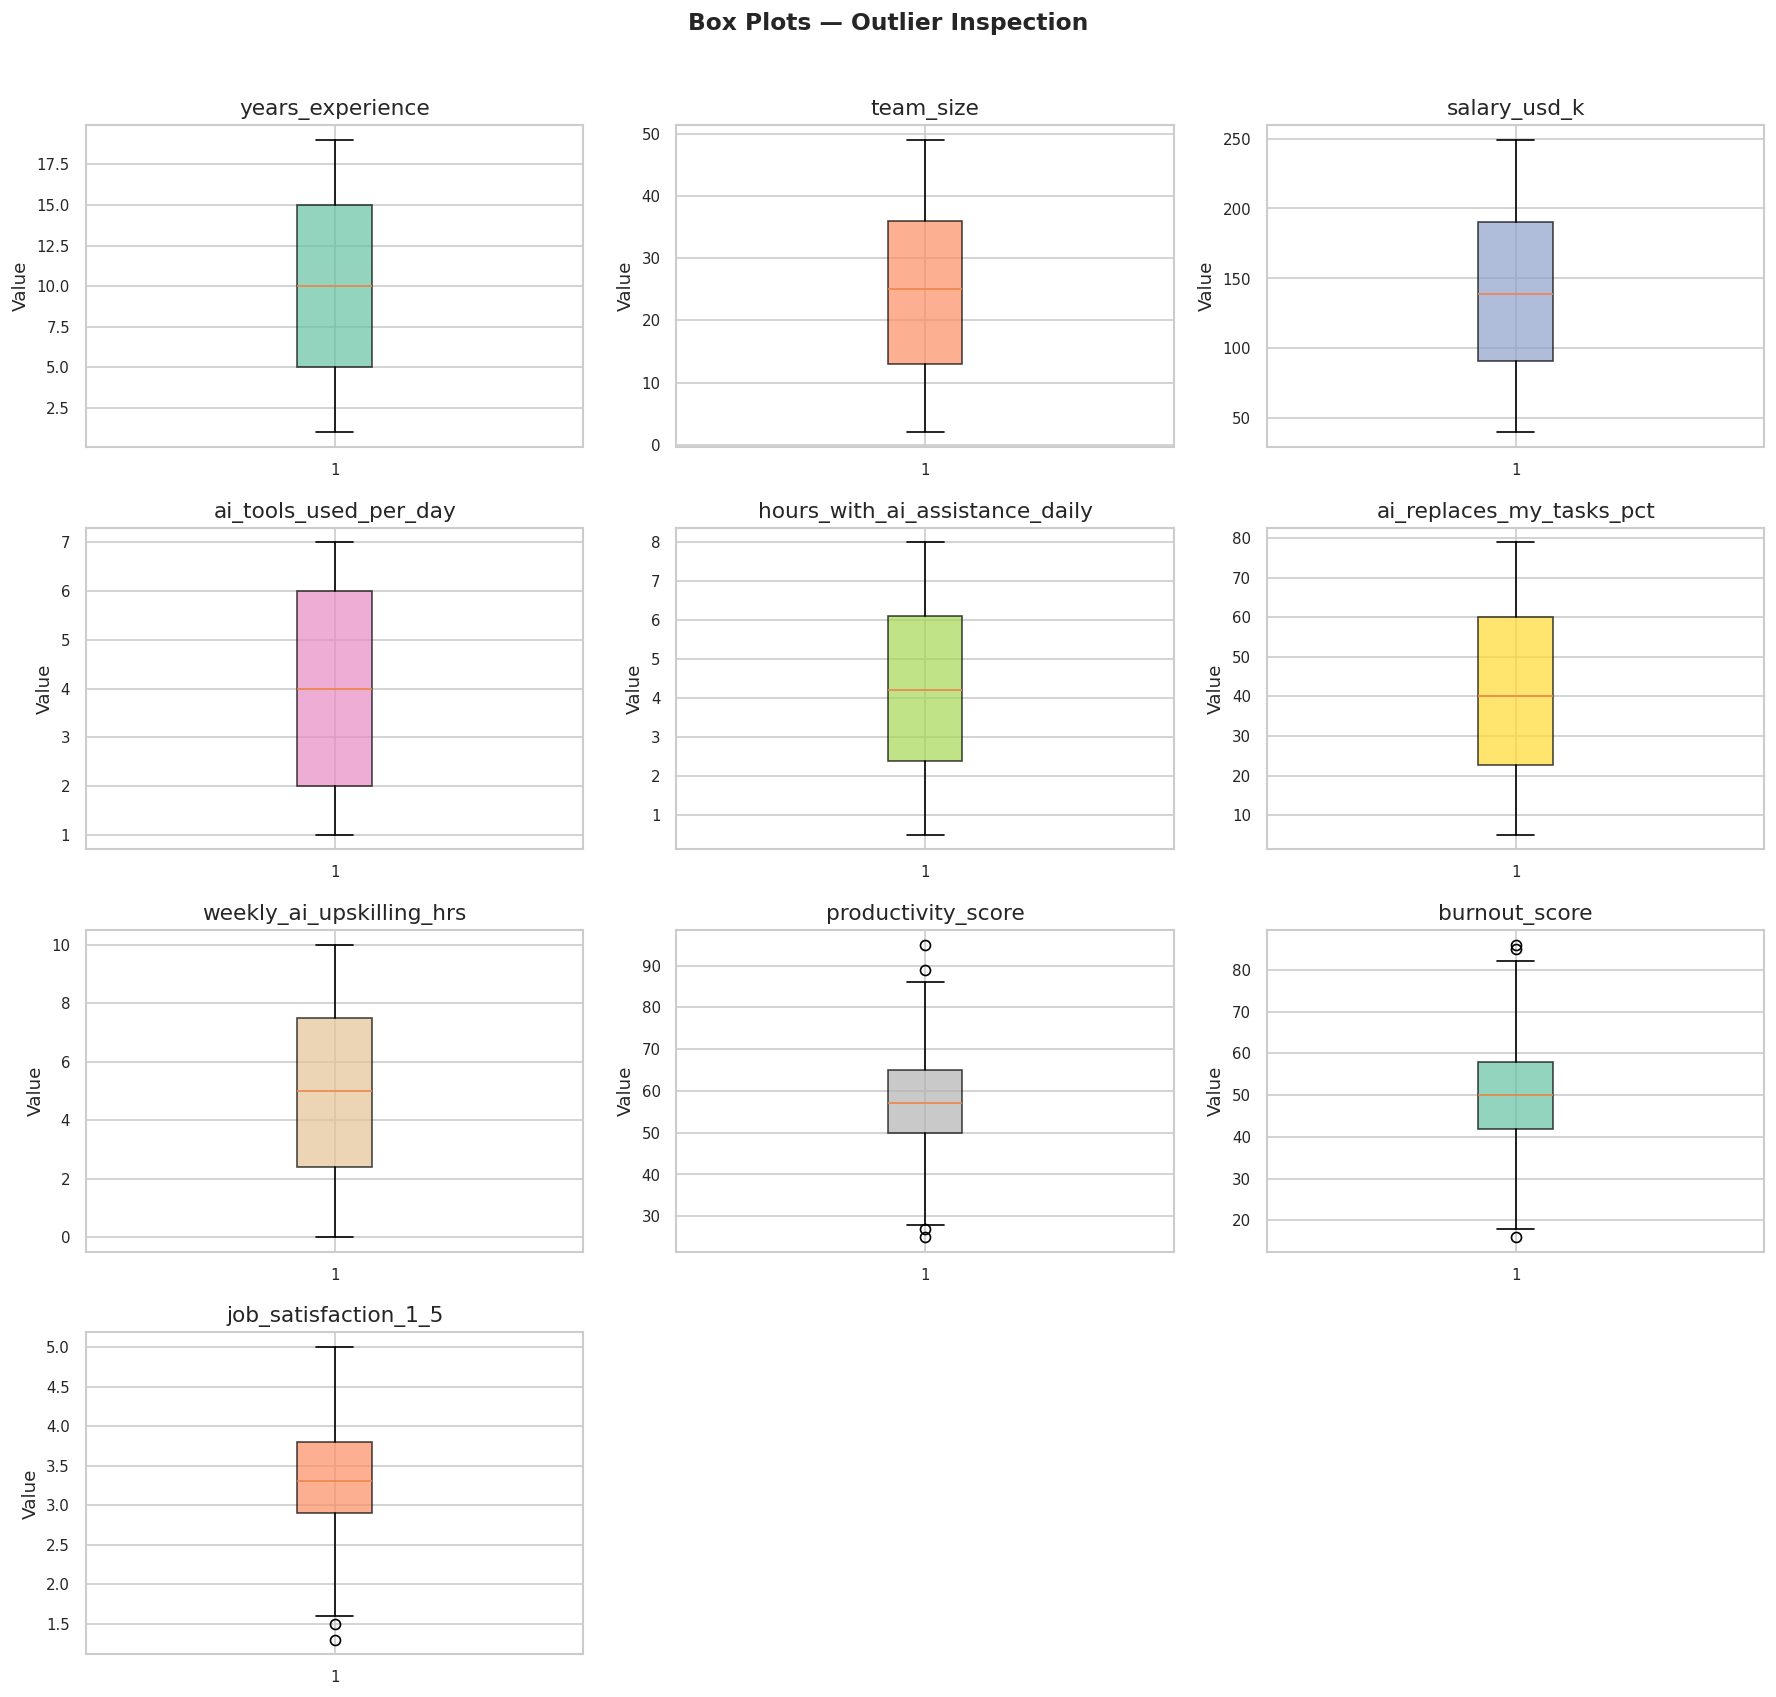

In [60]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(plot_num):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=PALETTE[i % len(PALETTE)], alpha=0.7))
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots — Outlier Inspection', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 4.3 Categorical Feature Distributions

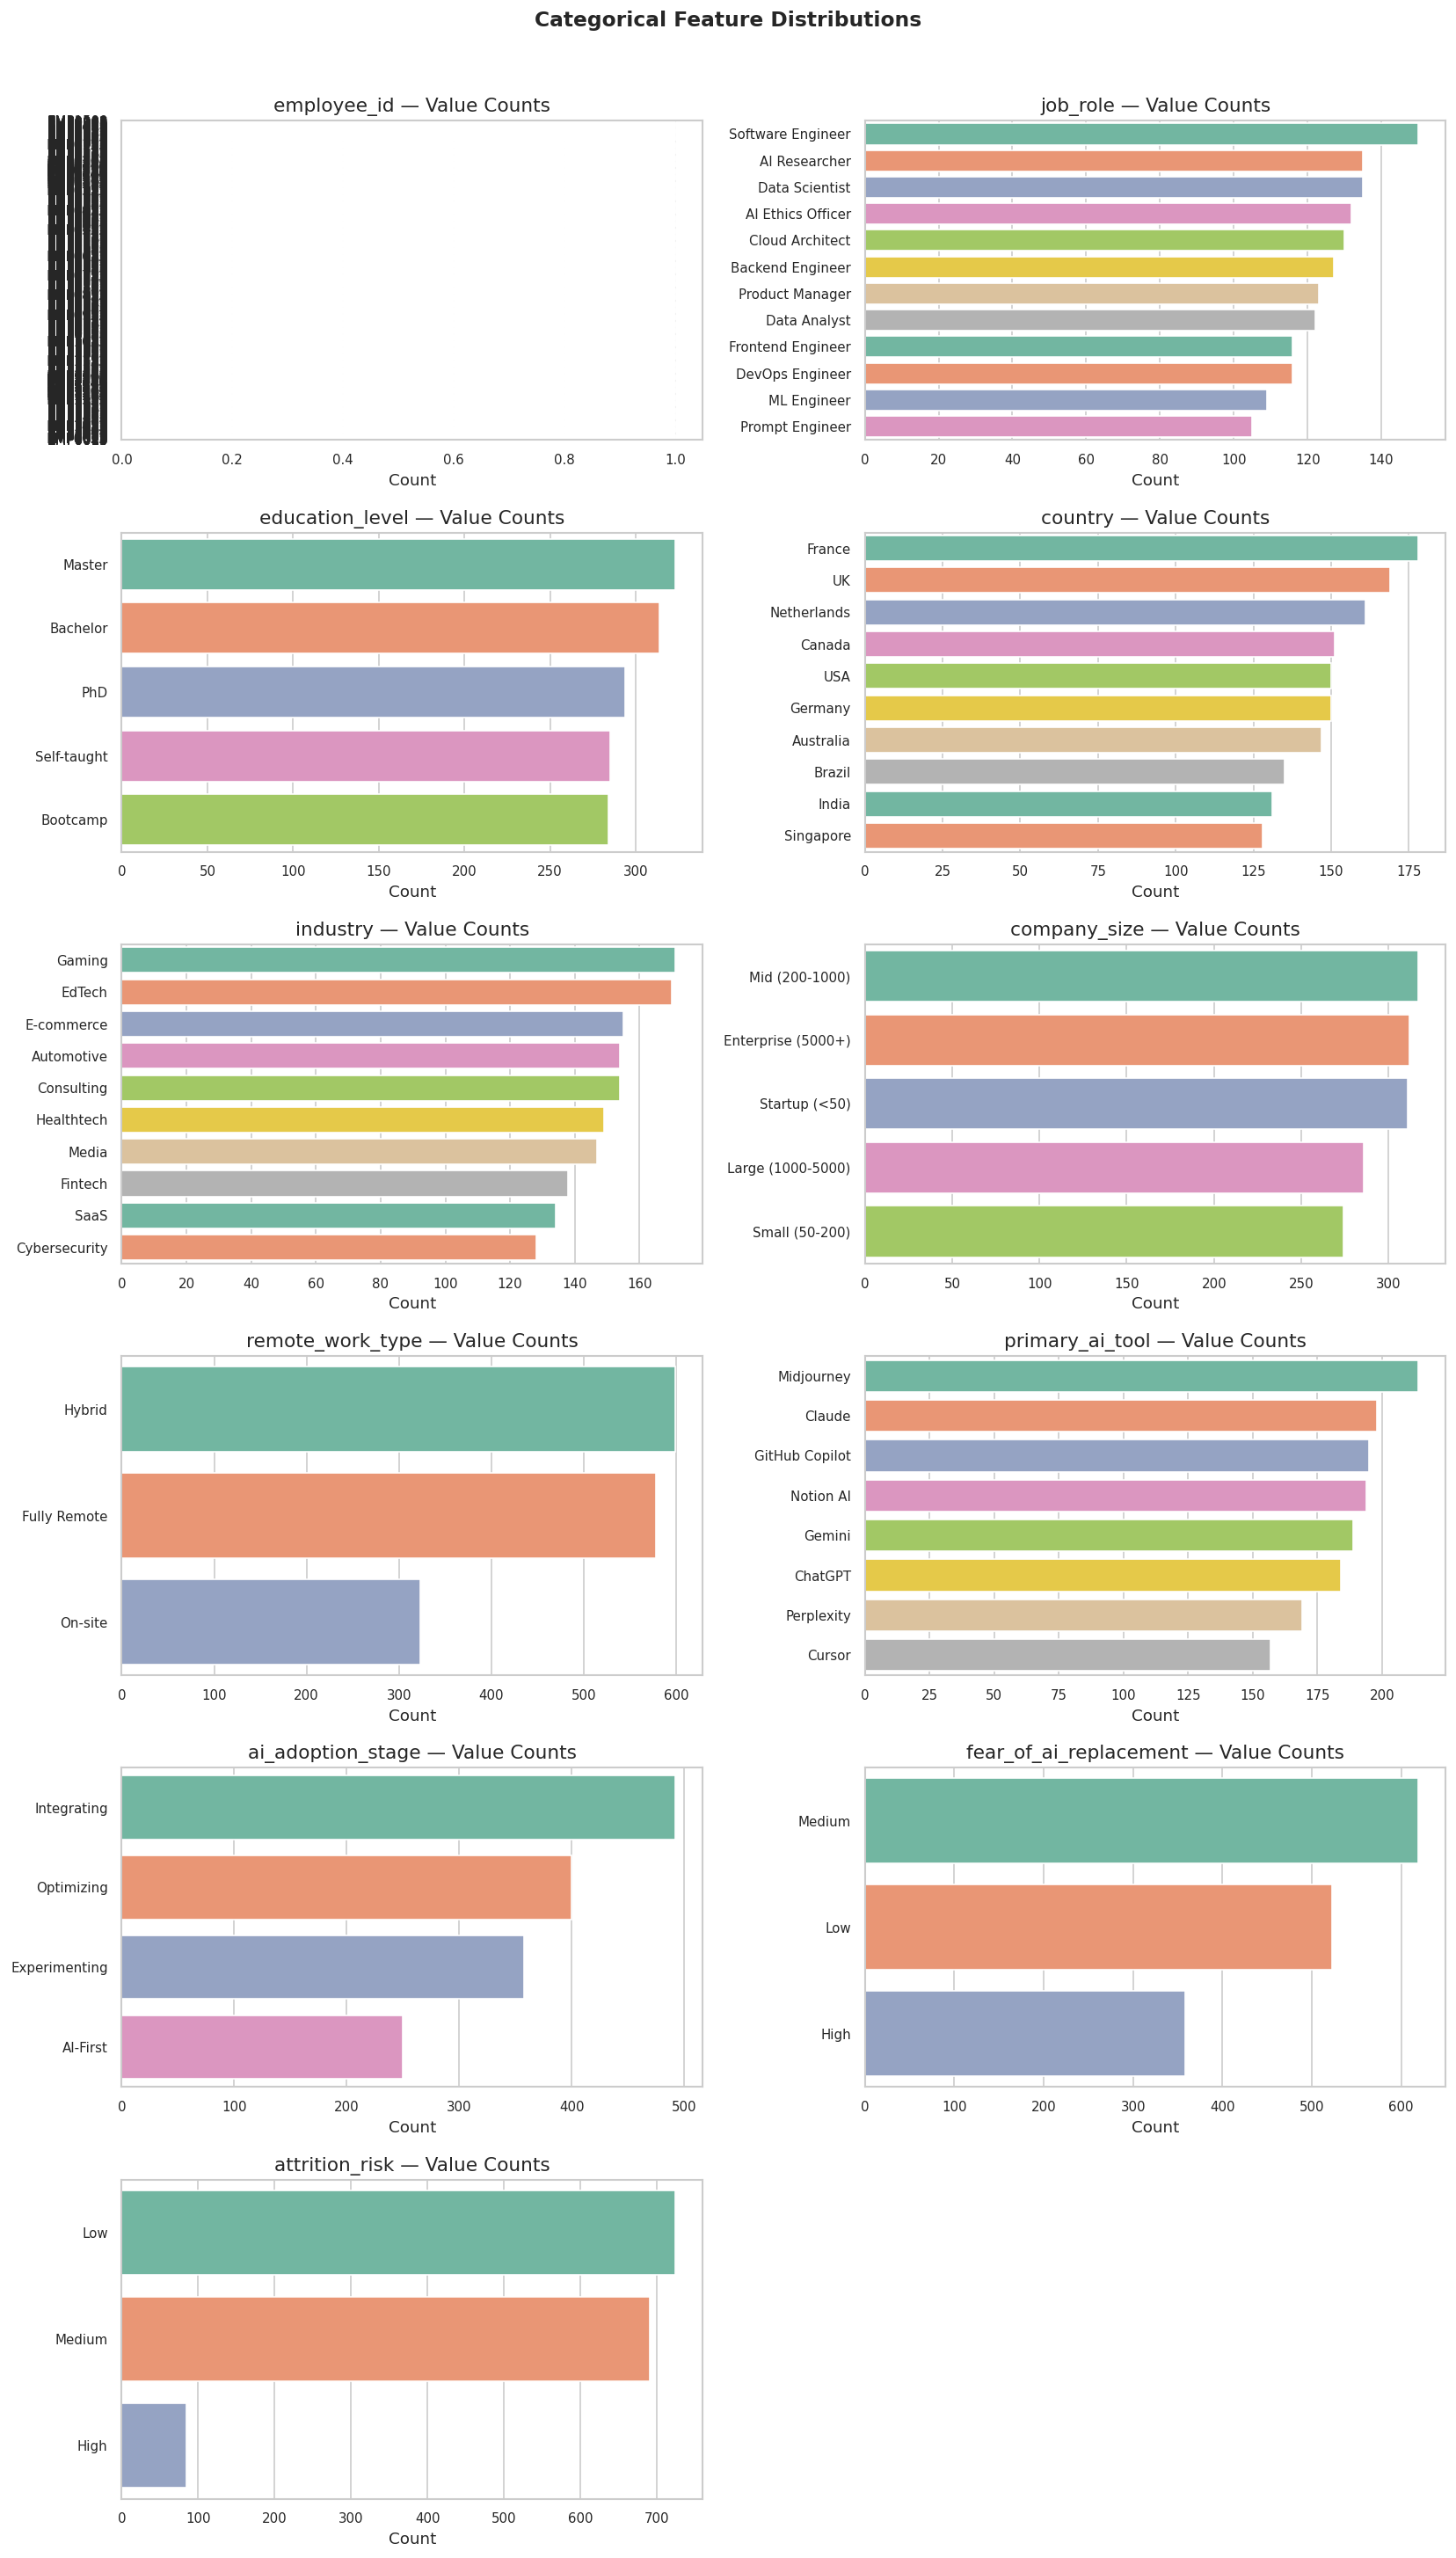

In [61]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

ncols_c = 2
nrows_c = (len(cat_cols) + ncols_c - 1) // ncols_c

fig, axes = plt.subplots(nrows_c, ncols_c, figsize=(14, nrows_c * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[i],
                  palette='Set2', edgecolor='white')
    axes[i].set_title(f'{col} — Value Counts')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 4.4 Burnout Score Distribution by Attrition Risk

We hypothesize that higher burnout scores are associated with higher attrition risk. This KDE plot tests that hypothesis visually.

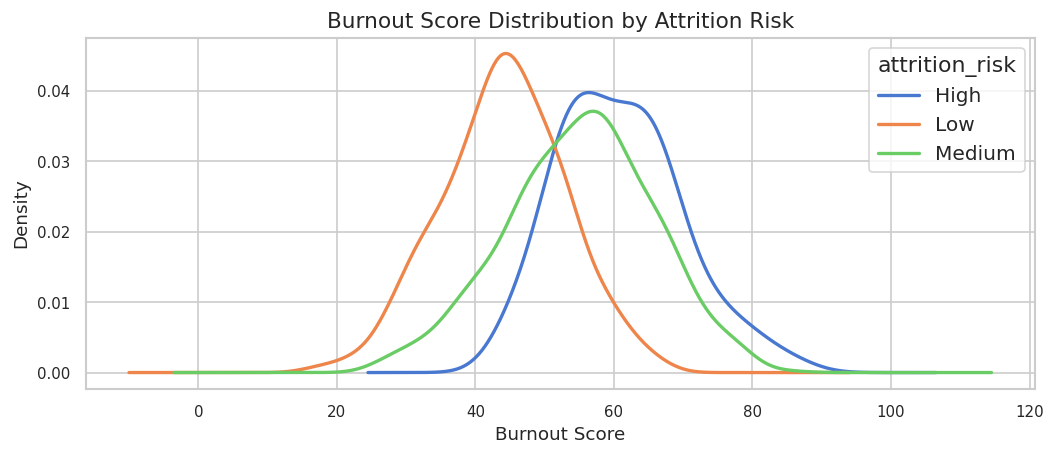

In [62]:
burnout_col = 'burnout_score'
target_col  = 'attrition_risk'

fig, ax = plt.subplots(figsize=(9, 4))
for label, grp in df.groupby(target_col):
    grp[burnout_col].dropna().plot.kde(ax=ax, label=str(label), linewidth=2)

ax.set_title('Burnout Score Distribution by Attrition Risk')
ax.set_xlabel('Burnout Score')
ax.legend(title=target_col)
plt.tight_layout()
plt.show()

# 4.5 Correlation Heatmap

The heatmap reveals multicollinearity among features. Highly correlated feature pairs (|r| > 0.85) are candidates for removal to reduce redundancy and avoid model instability.

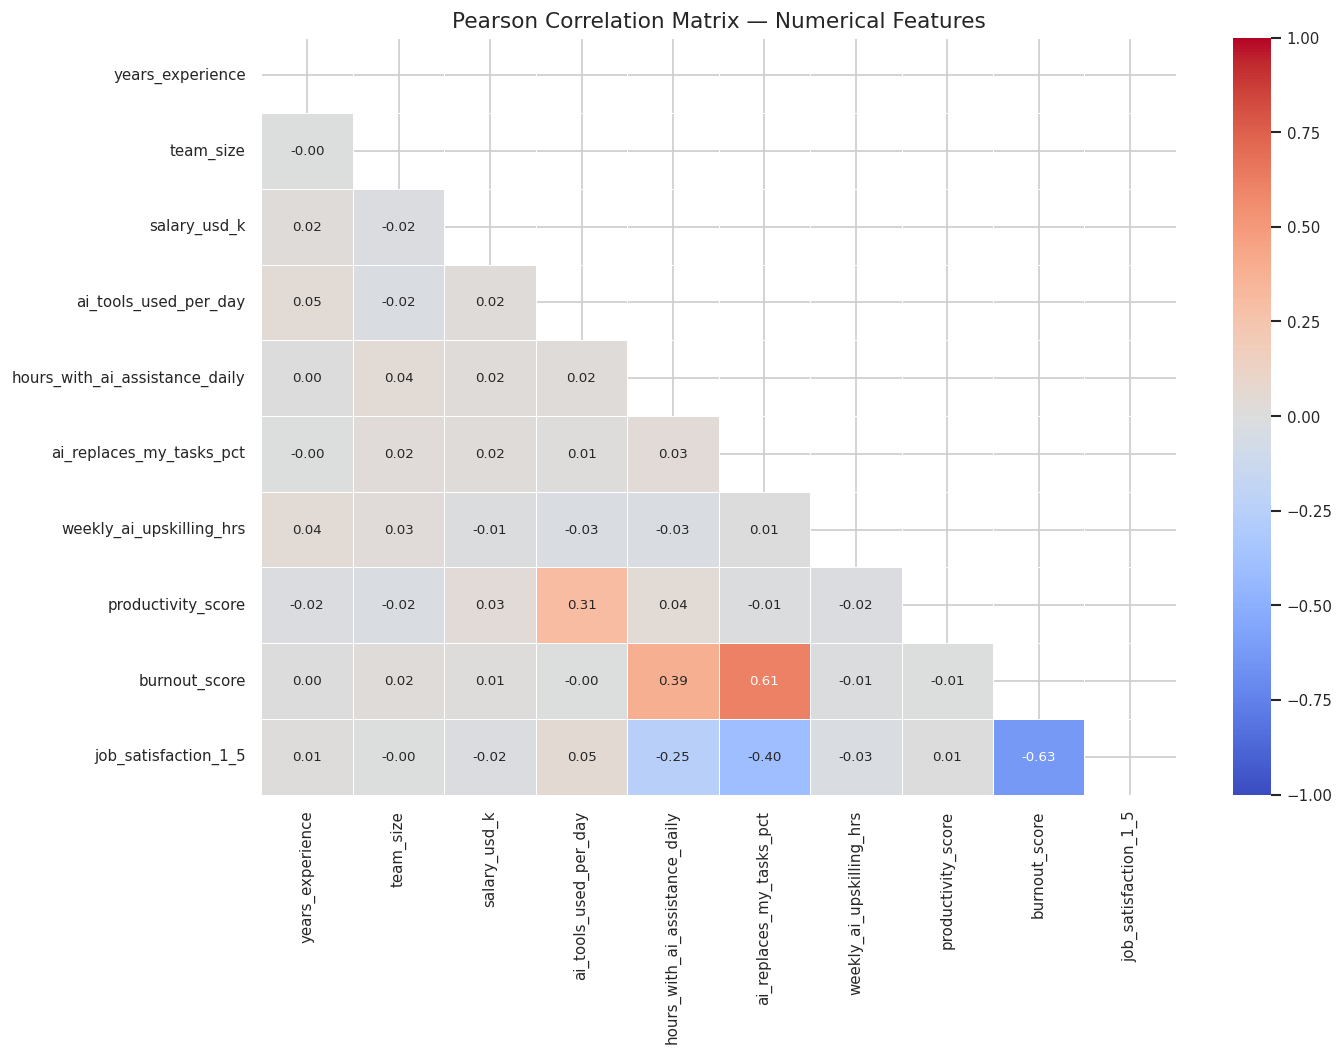

In [63]:
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 8})
ax.set_title('Pearson Correlation Matrix — Numerical Features', fontsize=13)
plt.tight_layout()
plt.show()

# 4.6 Burnout Score by Job Role (Violin Plot)

Violin plots show both the distribution shape and summary statistics per category. Roles with consistently high burnout distributions may be priority targets for HR intervention.

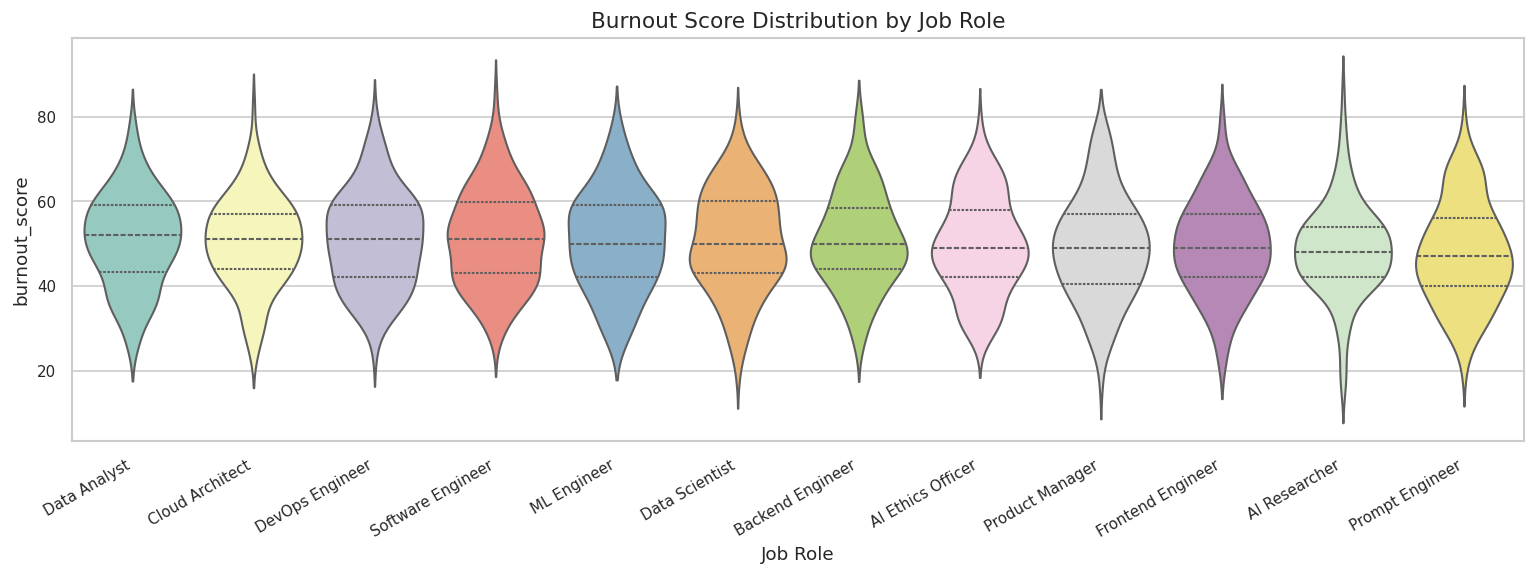

In [64]:
role_col    = 'job_role'

order = df.groupby(role_col)[burnout_col].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(13, 5))
sns.violinplot(data=df, x=role_col, y=burnout_col, order=order,
               palette='Set3', inner='quartile', ax=ax)
ax.set_title('Burnout Score Distribution by Job Role')
ax.set_xlabel('Job Role')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# 4.7 Attrition Risk Across Categorical Features (Stacked Bar)

Stacked proportional bars show which categories within each feature are most associated with high attrition risk — directly relevant to our research question on early warning indicator

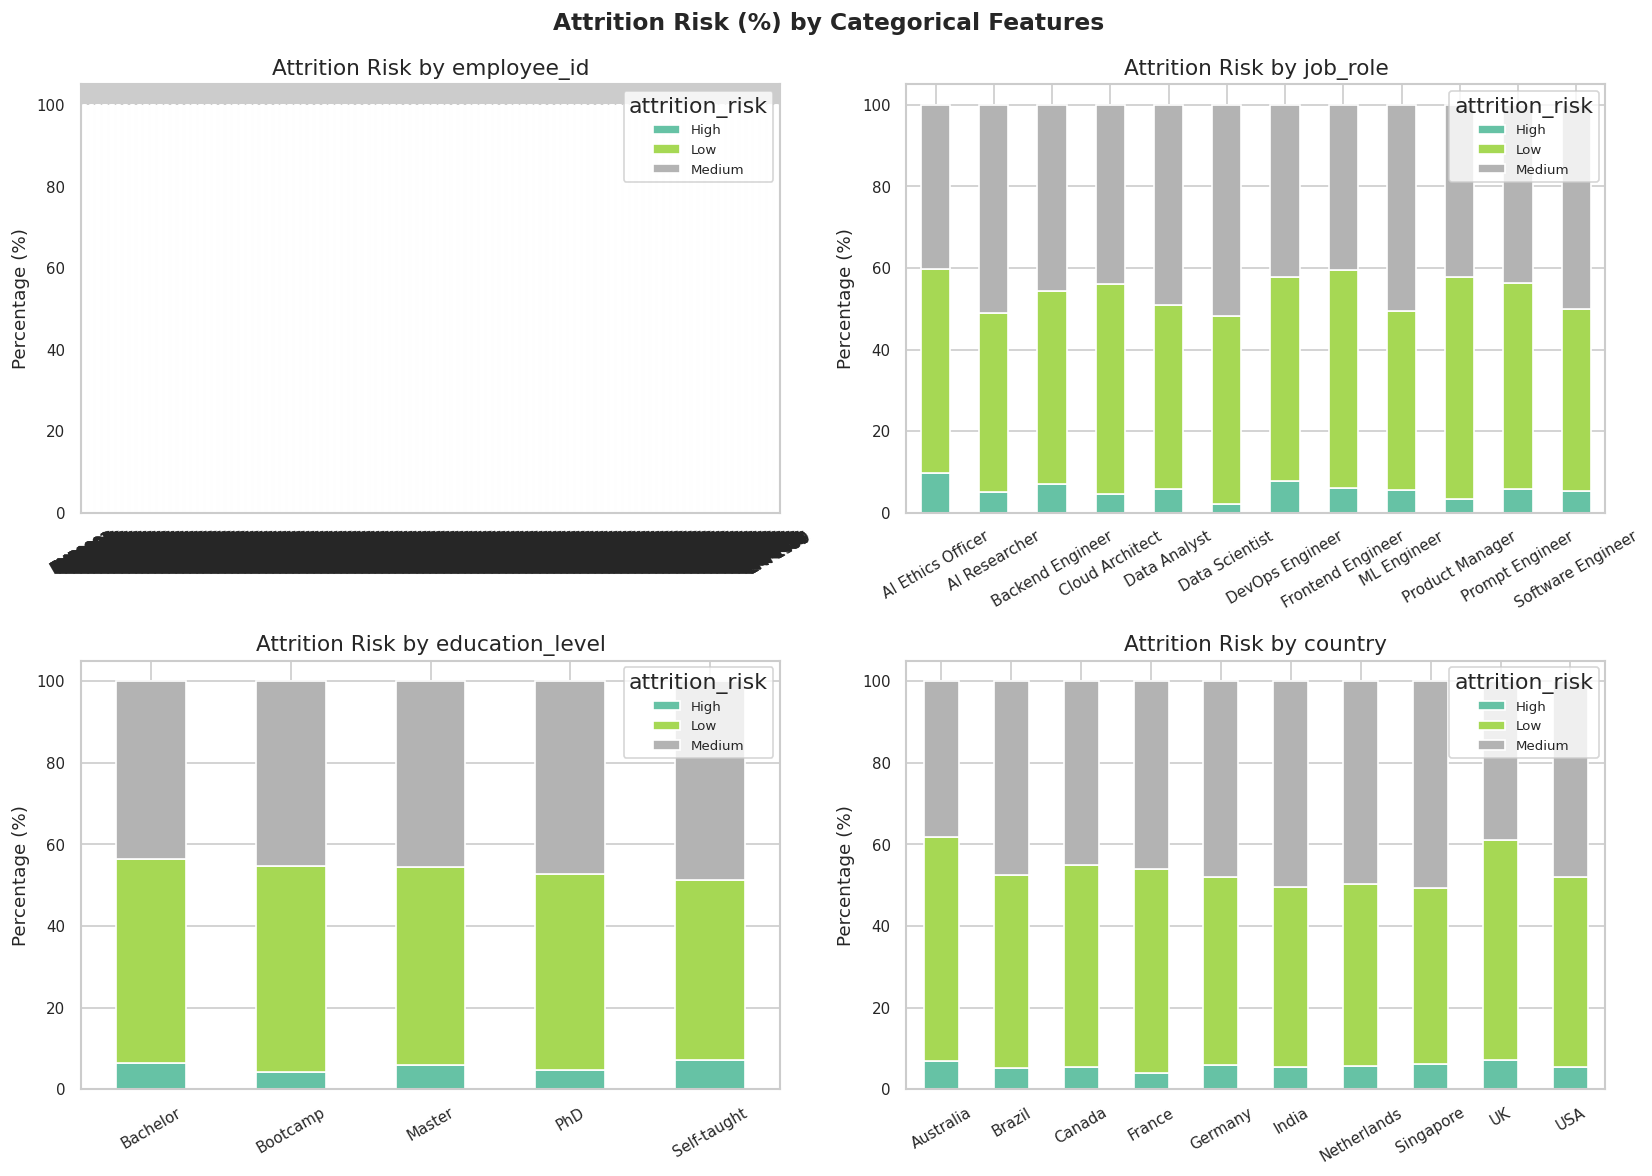

In [65]:
# Show top 4 most informative categorical features
top_cats = cat_cols[:4] if len(cat_cols) >= 4 else cat_cols

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(top_cats):
    ct = pd.crosstab(df[col], df[target_col], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='Set2', edgecolor='white')
    axes[i].set_title(f'Attrition Risk by {col}')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title=target_col, loc='upper right', fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Attrition Risk (%) by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4.8 AI Tool Usage vs Burnout Score

A key novelty of our research is exploring whether heavy reliance on AI tools paradoxically increases burnout. This box plot investigates that relationship.

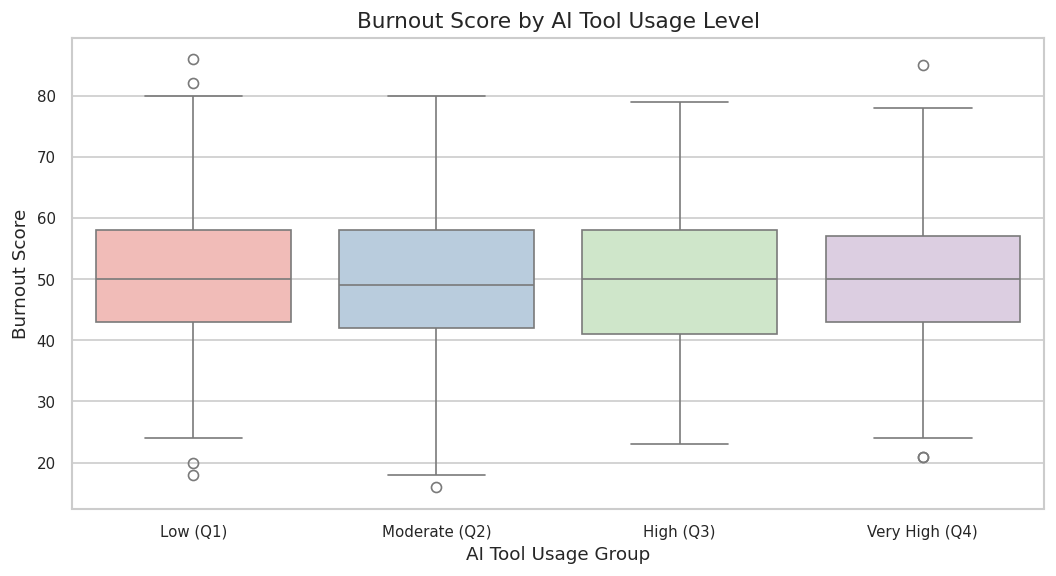

In [66]:
ai_col      = 'ai_tools_used_per_day'

# Bin AI usage into quartile-based groups for cleaner visualization
df['AI_Usage_Group'] = pd.qcut(df[ai_col], q=4,
                                labels=['Low (Q1)', 'Moderate (Q2)',
                                        'High (Q3)', 'Very High (Q4)'])

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='AI_Usage_Group', y=burnout_col, palette='Pastel1', ax=ax)
ax.set_title('Burnout Score by AI Tool Usage Level')
ax.set_xlabel('AI Tool Usage Group')
ax.set_ylabel('Burnout Score')
plt.tight_layout()
plt.show()

# 4.9 Pair Plot — Key Numerical Features Colored by Attrition Risk

Pair plots reveal inter-feature relationships and linear separability between classes. If groups are visually separable, even simple classifiers may perform well.

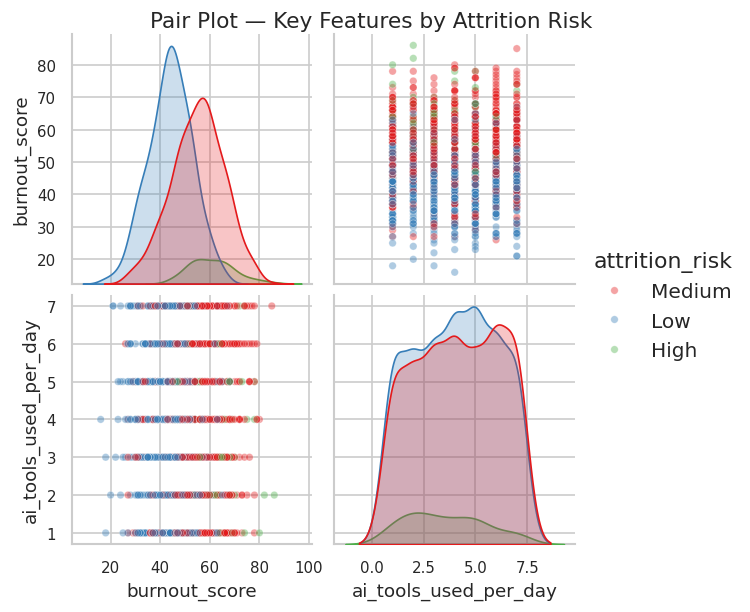

In [67]:
# Select most relevant numerics for pair plot (limit to avoid clutter)
pair_features = [burnout_col, hours_col, ai_col, target_col]
pair_features = [c for c in pair_features if c in df.columns]

sns.pairplot(df[pair_features].dropna(), hue=target_col,
             diag_kind='kde', plot_kws={'alpha': 0.4, 's': 20},
             palette='Set1')
plt.suptitle('Pair Plot — Key Features by Attrition Risk', y=1.01, fontsize=13)
plt.show()

# 4.10 Burnout vs Job Satisfaction

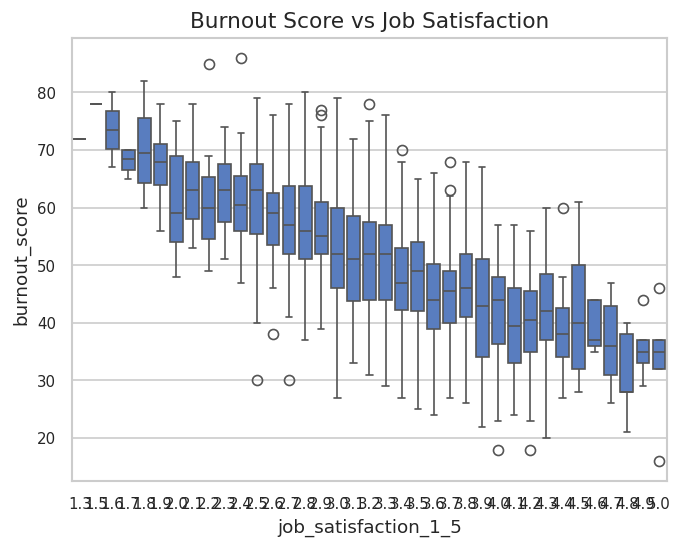

In [68]:
sns.boxplot(x='job_satisfaction_1_5', y='burnout_score', data=df)
plt.title("Burnout Score vs Job Satisfaction")
plt.show()

Workers with lower job satisfaction tend to have higher burnout scores.

# 4.11 AI Usage vs Productivity

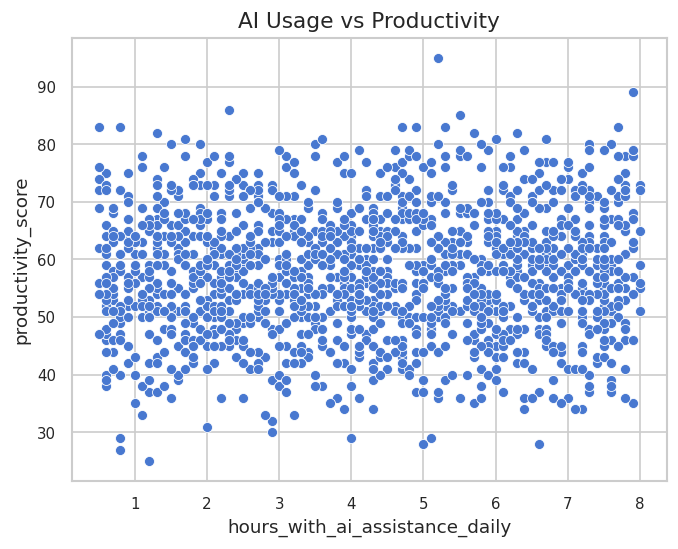

In [69]:
sns.scatterplot(x='hours_with_ai_assistance_daily', y='productivity_score', data=df)
plt.title("AI Usage vs Productivity")
plt.show()

This plot helps analyze whether increased AI assistance improves productivity.

# 4.12 Salary Distribution

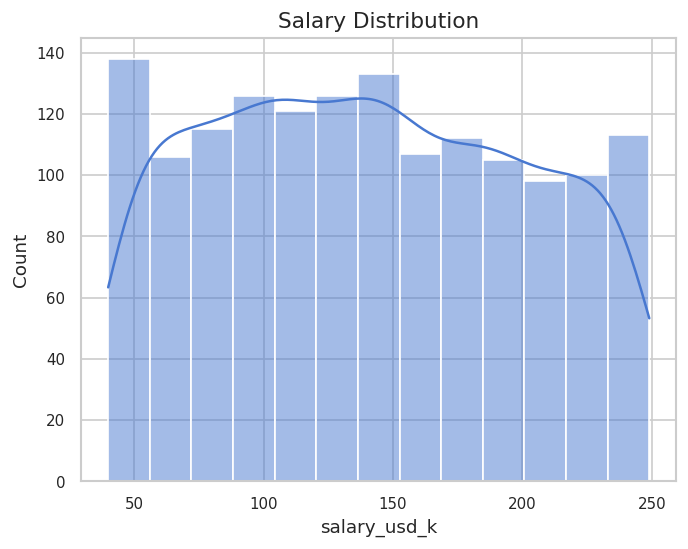

In [70]:
sns.histplot(df['salary_usd_k'], kde=True)
plt.title("Salary Distribution")
plt.show()

The salary distribution shows the spread of compensation among AI workers.

# 4.13 Job Role Distribution

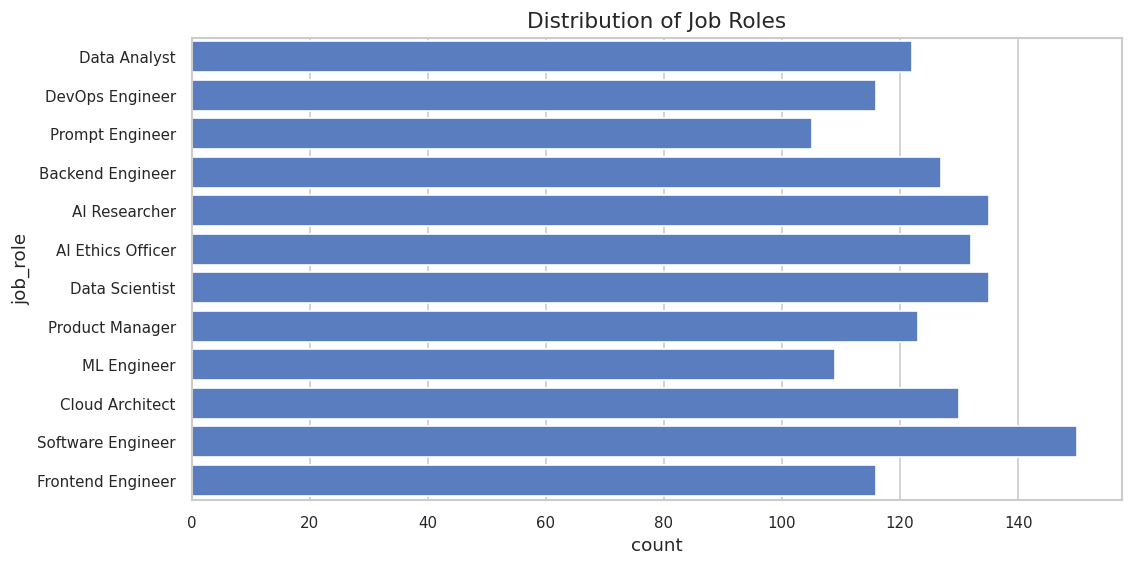

In [71]:
plt.figure(figsize=(10,5))
sns.countplot(y='job_role', data=df)
plt.title("Distribution of Job Roles")
plt.show()

This plot shows the number of workers in different AI-related roles.

# **5. Preprocessing**

Each step below is justified. No transformation is done without a reason.

# 5.1 Drop Duplicate Rows

In [72]:
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f'Rows before: {before} | Rows after: {after} | Dropped: {before - after}')

Rows before: 1500 | Rows after: 1500 | Dropped: 0


no duplicates found

# 5.2 Check Missing Values

In [73]:
from sklearn.impute import SimpleImputer

num_cols_cur = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_cur = df.select_dtypes(include='object').columns.tolist()

# Numerical: impute with median (robust to outliers)
if df[num_cols_cur].isnull().any().any():
    num_imp = SimpleImputer(strategy='median')
    df[num_cols_cur] = num_imp.fit_transform(df[num_cols_cur])
    print('Numerical missing values imputed with median')
else:
    print('No missing values in numerical features')

# Categorical: impute with most frequent value
if df[cat_cols_cur].isnull().any().any():
    cat_imp = SimpleImputer(strategy='most_frequent')
    df[cat_cols_cur] = cat_imp.fit_transform(df[cat_cols_cur])
    print('Categorical missing values imputed with mode')
else:
    print('No missing values in categorical features')

No missing values in numerical features
No missing values in categorical features


# 5.3 Drop Irrelevant / High-Cardinality Identifier Columns

In [74]:
id_cols = [c for c in df.columns if c.lower() in ['employee_id', 'id', 'name', 'emp_id']]
print(f'Identifier columns detected: {id_cols}')

if id_cols:
    df.drop(columns=id_cols, inplace=True)
    print(f'Dropped: {id_cols}')
else:
    print('No pure identifier columns found — nothing dropped.')

Identifier columns detected: ['employee_id']
Dropped: ['employee_id']


Identifier columns (e.g., Employee ID) carry zero predictive information. Including them can cause data leakage and explode the feature space during encoding.

# 5.4 Outlier Treatment — IQR Capping (Winsorization)

In [75]:
# Apply IQR-based capping to numerical columns (excluding binary columns)
outlier_cols = [c for c in num_cols_cur if df[c].nunique() > 10]

for col in outlier_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    clipped = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower, upper)
    if clipped > 0:
        print(f'{col}: {clipped} values capped')

print('\nOutlier capping complete')

productivity_score: 4 values capped
burnout_score: 3 values capped
job_satisfaction_1_5: 2 values capped

Outlier capping complete


# 5.5 Encoding Categorical Features

In [76]:
from sklearn.preprocessing import LabelEncoder

cat_cols_cur = df.select_dtypes(include='object').columns.tolist()

# Separate target from features for encoding strategy
feature_cats = [c for c in cat_cols_cur if c != target_col]

# Low-cardinality categoricals (≤5 unique values): One-Hot Encode
low_card  = [c for c in feature_cats if df[c].nunique() <= 5]
# High-cardinality (>5 unique values): Label Encode to avoid dimension explosion
high_card = [c for c in feature_cats if df[c].nunique() >  5]

print(f'One-Hot Encode  → {low_card}')
print(f'Label Encode    → {high_card}')

# One-Hot Encoding
if low_card:
    df = pd.get_dummies(df, columns=low_card, drop_first=True)

# Label Encoding
le = LabelEncoder()
for col in high_card:
    df[col] = le.fit_transform(df[col].astype(str))

# Encode Target
if df[target_col].dtype == 'object':
    df[target_col] = le.fit_transform(df[target_col].astype(str))
    print(f'\nTarget "{target_col}" label-encoded ')

print(f'\nShape after encoding: {df.shape}')

One-Hot Encode  → ['education_level', 'company_size', 'remote_work_type', 'ai_adoption_stage', 'fear_of_ai_replacement']
Label Encode    → ['job_role', 'country', 'industry', 'primary_ai_tool']

Target "attrition_risk" label-encoded 

Shape after encoding: (1500, 31)


Machine learning models require numerical inputs. One-Hot Encoding is used for low-cardinality features (e.g., Gender, Employment Type) because it avoids imposing an artificial ordinal relationship between categories. For high-cardinality features (e.g., Job Role if many roles exist), Label Encoding is preferred to prevent the feature matrix from becoming too wide (curse of dimensionality).

# 5.6 Drop Temporary Helper Columns

In [77]:
# Drop the binned column created only for visualization
if 'AI_Usage_Group' in df.columns:
    df.drop(columns=['AI_Usage_Group'], inplace=True)
    print('Dropped helper column: AI_Usage_Group')

Dropped helper column: AI_Usage_Group


AI_Usage_Group was engineered purely for the visualization in Section 4.9 and is derived directly from `ai_tools_used_per_day`. Keeping it would introduce a redundant feature with perfect linear dependence on its parent column.

# 5.7 Feature Scaling — StandardScaler

In [78]:
from sklearn.preprocessing import StandardScaler

# Scale all numerical features EXCEPT the target
scale_cols = [c for c in df.select_dtypes(include=[np.number]).columns
              if c != target_col and df[c].nunique() > 5]

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print(f'Scaled {len(scale_cols)} numerical features')
print(df[scale_cols].describe().T[['mean','std']].head(10))

Scaled 14 numerical features
                                        mean       std
job_role                        9.473903e-18  1.000334
years_experience                4.263256e-17  1.000334
country                         8.052818e-17  1.000334
industry                       -1.278977e-16  1.000334
team_size                       1.136868e-16  1.000334
salary_usd_k                   -1.373716e-16  1.000334
primary_ai_tool                 9.473903e-17  1.000334
ai_tools_used_per_day          -2.131628e-17  1.000334
hours_with_ai_assistance_daily -4.736952e-18  1.000334
ai_replaces_my_tasks_pct        6.779762e-17  1.000334


Features in this dataset have very different scales (e.g.`years_experience` vs `burnout_score` ~0–10). StandardScaler transforms each feature to zero mean and unit variance, which is critical for gradient-based models (Logistic Regression, Neural Networks) and distance-based models (KNN, SVM). Tree-based models (Random Forest, XGBoost) are scale-invariant but scaling does not harm them either.

# 5.8 Target Variable Distribution

In [79]:
# Check distribution of target variables
print("Attrition Risk Distribution:")
print(df['attrition_risk'].value_counts())
print("\nPercentage:")
print(df['attrition_risk'].value_counts(normalize=True) * 100)

# Also check burnout score distribution (for regression task)
print("\nBurnout Score Statistics:")
print(df['burnout_score'].describe())
# Imbalance ratio: High risk is underrepresented
majority = df['attrition_risk'].value_counts().max()
minority = df['attrition_risk'].value_counts().min()
print(f'Imbalance ratio (Low:High) = {majority/minority:.1f}:1')

Attrition Risk Distribution:
attrition_risk
1    724
2    691
0     85
Name: count, dtype: int64

Percentage:
attrition_risk
1    48.266667
2    46.066667
0     5.666667
Name: proportion, dtype: float64

Burnout Score Statistics:
count    1.500000e+03
mean    -1.764514e-16
std      1.000334e+00
min     -2.807734e+00
25%     -7.054811e-01
50%     -4.730070e-03
75%      6.960210e-01
max      2.798274e+00
Name: burnout_score, dtype: float64
Imbalance ratio (Low:High) = 8.5:1


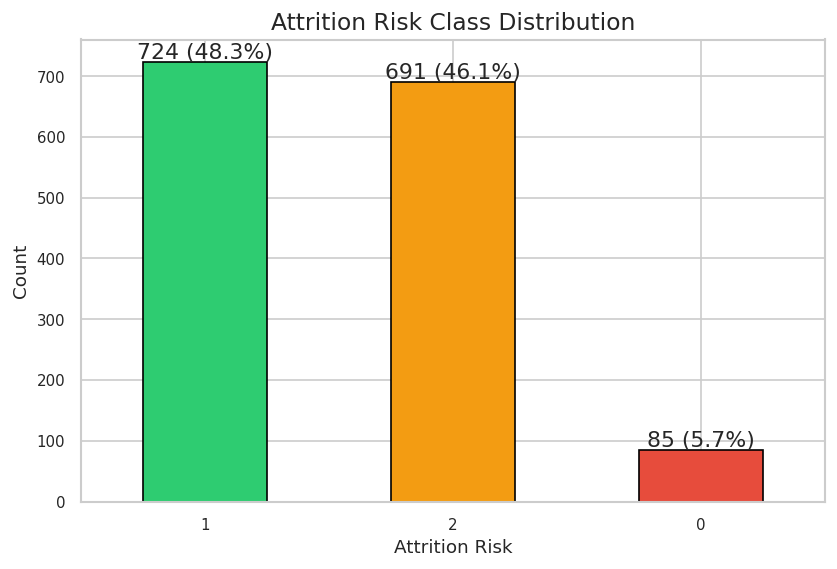

In [80]:
# Visualize attrition risk imbalance
plt.figure(figsize=(8,5))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
df['attrition_risk'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Attrition Risk Class Distribution', fontsize=14)
plt.xlabel('Attrition Risk')
plt.ylabel('Count')
plt.xticks(rotation=0)
# Add percentage labels on bars
for i, v in enumerate(df['attrition_risk'].value_counts().values):
    plt.text(i, v + 5, f'{v} ({v/len(df)*100:.1f}%)', ha='center')
plt.show()

The attrition_risk target is imbalanced: only 5.7% of employees are labeled as High risk. This reflects real-world HR data where high-risk employees are a minority. For modeling, we must account for this imbalance using techniques like class weighting, SMOTE, or specialized metrics (precision/recall for the High class).

# 5.9 Final Dataset Verification

In [81]:
print('=== Final Dataset Summary ===')
print(f'Shape          : {df.shape}')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Dtypes         :\n{df.dtypes.value_counts()}')
df.head(3)

=== Final Dataset Summary ===
Shape          : (1500, 30)
Missing values : 0
Dtypes         :
bool       15
float64    14
int64       1
Name: count, dtype: int64


,job_role,years_experience,country,industry,team_size,salary_usd_k,primary_ai_tool,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,...,company_size_Mid (200-1000),company_size_Small (50-200),company_size_Startup (<50),remote_work_type_Hybrid,remote_work_type_On-site,ai_adoption_stage_Experimenting,ai_adoption_stage_Integrating,ai_adoption_stage_Optimizing,fear_of_ai_replacement_Low,fear_of_ai_replacement_Medium
0,-0.403767,-0.539893,0.165202,0.894413,-1.229174,0.724754,0.212970,-1.548618,-1.691942,-0.196234,...,False,False,False,False,False,True,False,False,True,False
1,0.165186,-1.272613,-0.881851,0.189040,1.256566,-1.503145,-1.551978,-0.535125,-1.691942,1.697443,...,False,False,False,True,False,True,False,False,False,True
2,1.303092,-1.272613,0.165202,-1.574393,0.891016,0.741505,0.654208,-0.028378,-0.108831,-0.842856,...,False,False,True,True,False,False,False,True,False,False


# 6. Save Preprocessed Dataset

In [82]:
output_path = '/kaggle/working/burnout_attrition_preprocessed.csv'
df.to_csv(output_path, index=False)
print(f'Preprocessed dataset saved to: {output_path}')
print(f'   Shape: {df.shape[0]} rows × {df.shape[1]} columns')

Preprocessed dataset saved to: /kaggle/working/burnout_attrition_preprocessed.csv
   Shape: 1500 rows × 30 columns
